# TBL data reduction

In [1]:
import plopp as pp
from ess.reduce import unwrap
from ess import tbl
import ess.tbl.data  # noqa: F401
from ess.imaging.types import *

## Create and configure the workflow

In [2]:
wf = tbl.TblWorkflow()

wf[Filename[SampleRun]] = tbl.data.tutorial_sample_data()
wf[LookupTableFilename] = tbl.data.tbl_wavelength_lookup_table_no_choppers()

## nGEM detector data

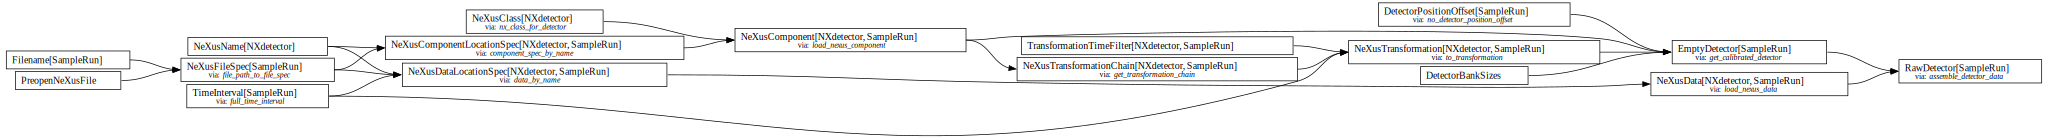

In [3]:
wf[NeXusDetectorName] = "ngem_detector"

wf.visualize(RawDetector[SampleRun], graph_attr={"rankdir": "LR"})

In [4]:
ngem = wf.compute(RawDetector[SampleRun])
ngem

<scipp.DataArray>
Dimensions: Sizes[dim_0:2, dim_1:128, dim_2:128, ]
Coordinates:
* detector_number             int32        <no unit>  (dim_0, dim_1, dim_2)  [1, 2, ..., 32767, 32768]
* position                  vector3              [m]  (dim_0, dim_1, dim_2)  [(-0.1488, 0.1488, -0.995), (-0.1465, 0.1488, -0.995), ..., (0.1465, -0.1488, -1.005), (0.1488, -0.1488, -1.005)]
* x_pixel_offset            float64              [m]  (dim_0, dim_1, dim_2)  [-0.1488, -0.1465, ..., 0.1465, 0.1488]
* y_pixel_offset            float64              [m]  (dim_0, dim_1, dim_2)  [0.1488, 0.1488, ..., -0.1488, -0.1488]
* z_pixel_offset            float64              [m]  (dim_0, dim_1, dim_2)  [0.005, 0.005, ..., -0.005, -0.005]
Data:
                          DataArrayView        <no unit>  (dim_0, dim_1, dim_2)  binned data: dim='event', content=DataArray(
          dims=(event: 352698),
          data=float32[counts],
          coords={'event_time_offset':int32[ns], 'event_time_zero':datetime64[ns]})

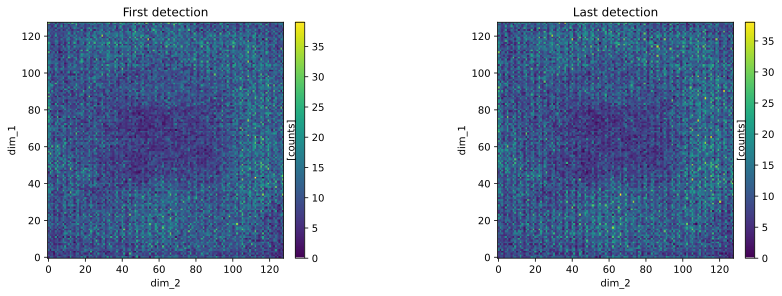

In [5]:
ngem['dim_0', 0].hist().plot(aspect='equal', title='First detection') + ngem['dim_0', 1].hist().plot(aspect='equal', title='Last detection')

### Neutron wavelengths

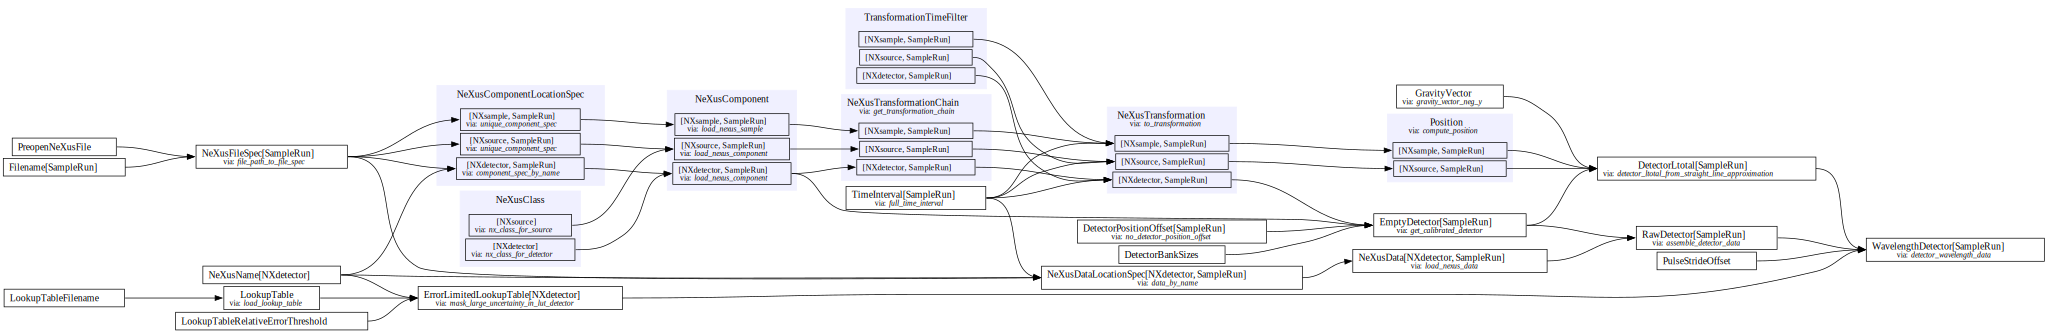

In [6]:
wf.visualize(WavelengthDetector[SampleRun], graph_attr={"rankdir": "LR"})

#### Visualize the wavelength lookup table

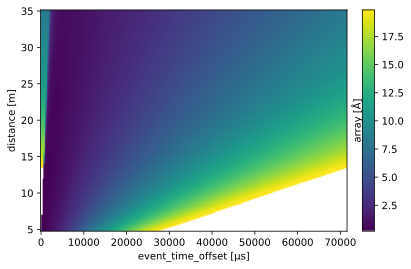

In [7]:
table = wf.compute(unwrap.LookupTable)
table.plot()

#### Results

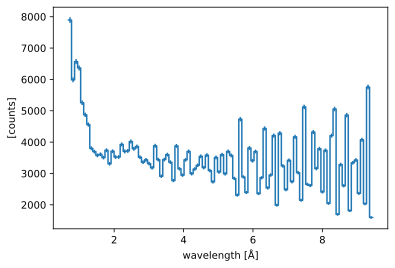

In [8]:
ngem_wavs = wf.compute(WavelengthDetector[SampleRun])

ngem_wavs.bins.concat().hist(wavelength=100).plot()

## He3 detector data

In [9]:
he3_wf = wf.copy()

he3 = {}
for bank in ('he3_detector_bank0', 'he3_detector_bank1'):
    he3_wf[NeXusDetectorName] = bank
    he3[bank] = he3_wf.compute(RawDetector[SampleRun])

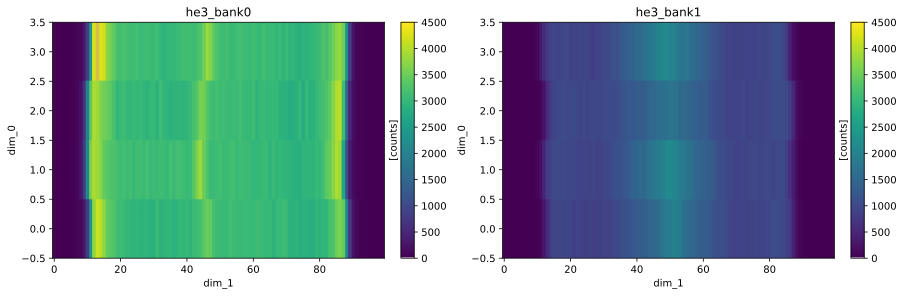

In [10]:
lims = {'vmin': 0, 'vmax': 4500}

he3['he3_detector_bank0'].hist().plot(title='he3_bank0', **lims) + he3['he3_detector_bank1'].hist().plot(title='he3_bank1', **lims)

### Neutron wavelengths

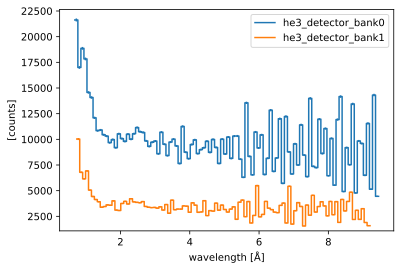

In [11]:
he3_wavs = {}

for bank in ('he3_detector_bank0', 'he3_detector_bank1'):
    he3_wf[NeXusDetectorName] = bank
    he3_wavs[bank] = he3_wf.compute(WavelengthDetector[SampleRun]).bins.concat().hist(wavelength=100)

pp.plot(he3_wavs)